In [1]:
import matplotlib.cm as cm
from matplotlib import colors
from matplotlib import pyplot as plt
from astropy.table import Table
import numpy as np
import os
import pandas as pd
import polars as pl
import scipy
import tqdm

In [ ]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [ ]:
gaiaids = pl.read_parquet('(#path to#)allgaiadata.parq').to_pandas()

In [ ]:
goldsample = pd.read_csv("(#path to#)oldcnnsample.csv", index_col='Unnamed: 0')

In [6]:
goldsample['bp-rp'] = goldsample['phot_bp_mean_mag']-goldsample['phot_rp_mean_mag']

In [7]:
minra = np.nanmin(gaiaids['ra_rad'].values)
maxra = np.nanmax(gaiaids['ra_rad'].values)
mindec = np.nanmin(gaiaids['dec_rad'].values)
maxdec = np.nanmax(gaiaids['dec_rad'].values)
allbins, allx, ally = np.histogram2d(gaiaids['ra_rad'],gaiaids['dec_rad'],bins=499,range=[[minra,maxra],[mindec,maxdec]])
prebins, px, py = np.histogram2d(goldsample['ra_rad'],goldsample['dec_rad'], bins=499,range=[[minra,maxra],[mindec,maxdec]])
totdet_fracradec = prebins/allbins

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_5960/35294173.py:7: RuntimeWarning: invalid value encountered in divide
  totdet_fracradec = prebins/allbins


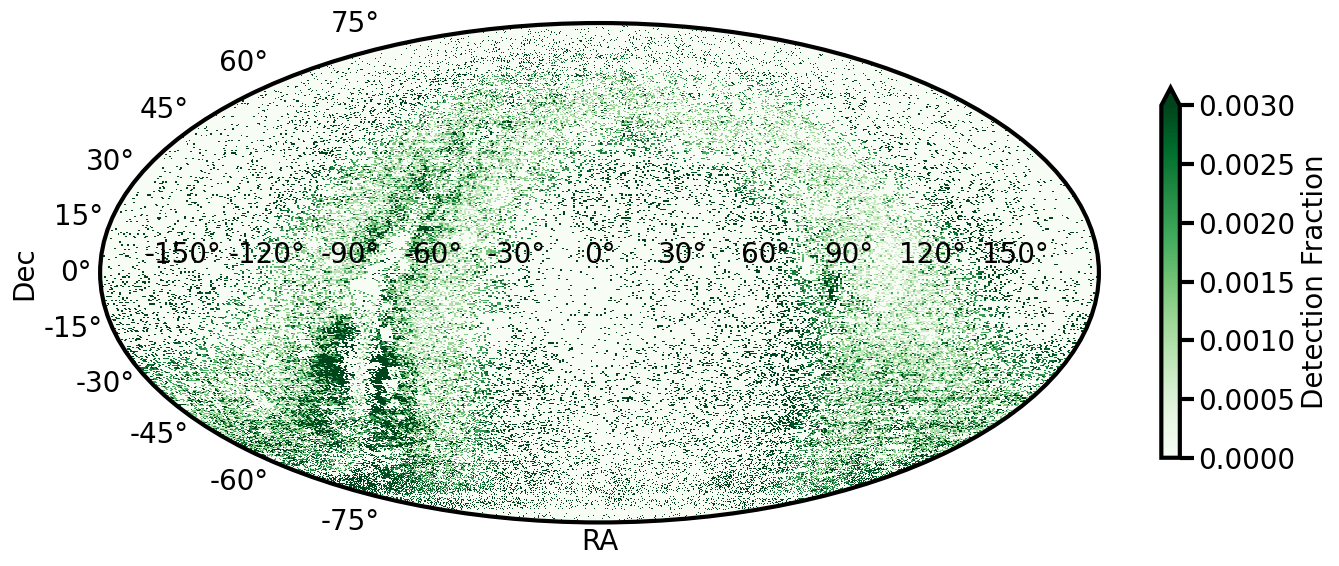

In [12]:
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='mollweide')
cmap = plt.cm.Greens
ax.pcolor(
    allx, ally,
    totdet_fracradec.T, cmap=cmap, shading='auto',vmin=0, vmax=0.003, rasterized=True)
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=colors.Normalize(0, 0.003), cmap=cmap), ax=ax, shrink=0.5,  extend='max')
cbar.set_label("Detection Fraction")
ax.set_ylabel('Dec')
ax.set_xlabel('RA')
plt.tight_layout()
plt.savefig('mollweide_detfraction.pdf', dpi=300)
plt.show()

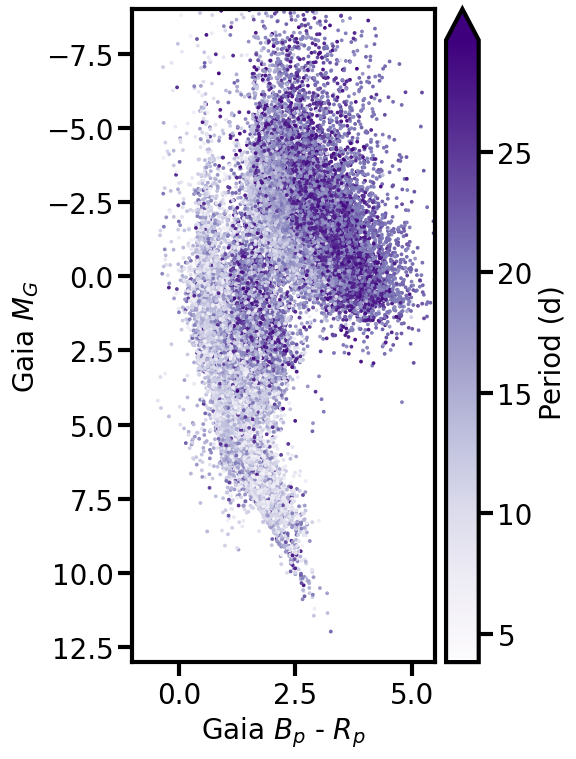

In [11]:
fig = plt.figure(figsize=(6, 8))
ax = fig.add_subplot(111)

norm = colors.Normalize(vmin=np.min(goldsample['period'].to_list()), vmax=np.max(goldsample['period'].to_list()))
cmap = plt.get_cmap('Purples')
ax.set(xlim=(-1, 5.5), ylim=(13, -9), xlabel='Gaia $B_p$ - $R_p$', ylabel=f'Gaia $M_G$')
im = ax.scatter(goldsample['bp-rp'], goldsample['abs_g_mag'], s=3, c=goldsample['period'], norm=norm, cmap=cmap, rasterized=True)

fig.colorbar(im, pad=0.03, label='Period (d)', extend='max')
plt.tight_layout()
plt.savefig('HR_periods.pdf', dpi=300)
plt.show()